# ChEMBL EGFR IC50 — Stratified Sampling

Fetches IC50 activity data for **EGFR (CHEMBL203)** from the ChEMBL REST API,
assigns chemical series via Murcko scaffold clustering, then applies
stratified sampling across *(series × pIC50 range)* strata with a guaranteed
minimum of 5 representatives per series.

**Sections**
1. Configuration  
2. Fetch data from ChEMBL  
3. Assign chemical series (Murcko scaffolds)  
4. Bin pIC50 into activity ranges  
5. Stratified sampling  
6. Validate with stratosampler metrics  
7. Report  
8. Visualise  
9. Export

In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Allow running from the notebooks/ directory without installing the package
sys.path.insert(0, str(Path().resolve().parent))

from stratosampler.splitters.property_stratified import PropertyStratifiedSplitter
from stratosampler.metrics.distribution import split_summary
from stratosampler.visualisation.plots import plot_series_sample

try:
    from rdkit import Chem
    from rdkit.Chem.Scaffolds import MurckoScaffold
    HAS_RDKIT = True
    print("RDKit available — Murcko scaffold clustering enabled.")
except ImportError:
    HAS_RDKIT = False
    print("WARNING: RDKit not found. Series assignment will fall back to ChEMBL ID prefix clusters.")

RDKit available — Murcko scaffold clustering enabled.


## 1. Configuration

Adjust these constants to change the target, sample size, or binning strategy.

In [2]:
TARGET_CHEMBL_ID = "CHEMBL203"          # EGFR, Homo sapiens
TARGET_NAME      = "EGFR"
CHEMBL_BASE      = "https://www.ebi.ac.uk/chembl/api/data"

MAX_RECORDS      = 500    # cap on how many activities to fetch
TOP_N_SERIES     = 5      # named scaffold series (+ "minor_series")
SAMPLE_FRACTION  = 0.30   # fraction to draw per stratum
MIN_PER_SERIES   = 5      # guaranteed minimum representatives per series
RANDOM_STATE     = 42

PIC50_BINS   = [0, 5, 6, 7, 8, 9, 15]
PIC50_LABELS = ["<5", "5-6", "6-7", "7-8", "8-9", ">=9"]

## 2. Fetch data from ChEMBL

Pulls IC50 records with pChEMBL values and SMILES strings.
Paginates automatically and deduplicates by `molecule_chembl_id`, keeping the best IC50.

In [3]:
def fetch_chembl_activity(target_id: str, max_records: int = 500) -> pd.DataFrame:
    url = f"{CHEMBL_BASE}/activity.json"
    base_params = {
        "target_chembl_id": target_id,
        "standard_type": "IC50",
        "standard_units": "nM",
        "pchembl_value__isnull": False,
        "limit": 100,
    }

    records: list[dict] = []
    offset = 0

    print(f"Fetching IC50 data for {target_id} from ChEMBL ...")
    while len(records) < max_records:
        resp = requests.get(url, params={**base_params, "offset": offset}, timeout=30)
        resp.raise_for_status()
        payload = resp.json()

        for act in payload.get("activities", []):
            smiles    = act.get("canonical_smiles")
            chembl_id = act.get("molecule_chembl_id")
            std_val   = act.get("standard_value")
            pchembl   = act.get("pchembl_value")
            if smiles and chembl_id and std_val and pchembl:
                try:
                    records.append({
                        "molecule_chembl_id": chembl_id,
                        "smiles": smiles,
                        "ic50_nm": float(std_val),
                        "pIC50": float(pchembl),
                    })
                except (TypeError, ValueError):
                    continue

        meta = payload.get("page_meta", {})
        if meta.get("next") is None or len(records) >= max_records:
            break
        offset += base_params["limit"]

    df = (
        pd.DataFrame(records)
        .drop_duplicates("molecule_chembl_id")
        .sort_values("pIC50", ascending=False)
        .reset_index(drop=True)
    )
    print(f"Retrieved {len(df)} unique compounds  "
          f"(pIC50 range: {df['pIC50'].min():.1f} – {df['pIC50'].max():.1f})")
    return df

In [4]:
df = fetch_chembl_activity(TARGET_CHEMBL_ID, max_records=MAX_RECORDS)
df.head()

Fetching IC50 data for CHEMBL203 from ChEMBL ...
Retrieved 362 unique compounds  (pIC50 range: 4.0 – 10.6)


,molecule_chembl_id,smiles,ic50_nm,pIC50
0,CHEMBL29197,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC,0.025,10.60
1,CHEMBL51853,Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.130,9.89
2,CHEMBL334697,C=CC(=O)N(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.170,9.77
3,CHEMBL53426,Brc1cccc(Nc2ncnc3cnc(NCCc4c[nH]cn4)nc23)c1,0.250,9.60
4,CHEMBL134371,O=C(O)/C=C/C(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,0.370,9.43


In [5]:
df["pIC50"].describe().round(3)

count    362.000
mean       6.595
std        1.480
min        4.000
25%        5.300
50%        6.465
75%        7.695
max       10.600
Name: pIC50, dtype: float64

## 3. Assign chemical series (Murcko scaffolds)

With RDKit: compute Murcko scaffolds, label the top-N most common ones as
`series_1 … series_N`, and collapse everything else into `minor_series`.

Without RDKit: fall back to ChEMBL ID numeric-range bucketing as a rough proxy.

In [6]:
def _murcko(smi: str) -> str:
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return "__invalid__"
        sc = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(sc)
    except Exception:
        return "__invalid__"


def _fallback_series(chembl_id: str) -> str:
    try:
        num = int(chembl_id.replace("CHEMBL", ""))
        bucket = (num // 50000) * 50000
        return f"id_group_{bucket}"
    except ValueError:
        return "misc"


def assign_series(df: pd.DataFrame, top_n: int = TOP_N_SERIES) -> pd.DataFrame:
    df = df.copy()
    if HAS_RDKIT:
        print("Computing Murcko scaffolds ...")
        df["scaffold"] = df["smiles"].map(_murcko)
        sc_counts = df["scaffold"].value_counts()
        top_scaffolds = sc_counts.head(top_n).index.tolist()
        series_map = {sc: f"series_{i+1}" for i, sc in enumerate(top_scaffolds)}
        df["series"] = df["scaffold"].map(lambda sc: series_map.get(sc, "minor_series"))
    else:
        df["series"] = df["molecule_chembl_id"].map(_fallback_series)

    counts = df["series"].value_counts()
    print("\nSeries composition (before sampling):")
    for series, n in counts.items():
        print(f"  {series:<20s}  {n:4d} compounds")
    return df

In [7]:
df = assign_series(df, top_n=TOP_N_SERIES)
df["series"].value_counts()

Computing Murcko scaffolds ...

Series composition (before sampling):
  minor_series           254 compounds
  series_1                35 compounds
  series_2                23 compounds
  series_3                18 compounds
  series_4                17 compounds
  series_5                15 compounds


series
minor_series    254
series_1         35
series_2         23
series_3         18
series_4         17
series_5         15
Name: count, dtype: int64

## 4. Bin pIC50 into activity ranges

In [8]:
def assign_pic50_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["pIC50_bin"] = pd.cut(
        df["pIC50"],
        bins=PIC50_BINS,
        labels=PIC50_LABELS,
        include_lowest=True,
    ).astype(str)
    return df

df = assign_pic50_bins(df)

# Full dataset heatmap: series × pIC50 bin
(
    df.groupby(["series", "pIC50_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PIC50_LABELS, fill_value=0)
)

pIC50_bin,<5,5-6,6-7,7-8,8-9,>=9
series,,,,,,
minor_series,33,74,65,34,35,13
series_1,1,4,5,13,7,5
series_2,15,5,3,0,0,0
series_3,0,0,0,2,8,8
series_4,2,8,3,4,0,0
series_5,0,0,11,4,0,0


## 5. Stratified sampling

**Algorithm**
1. Within each *(series, pIC50_bin)* stratum draw `floor(n × sample_fraction)` molecules (min 1).  
2. After the initial draw, check each series against `MIN_PER_SERIES`.  
3. If a series is under-represented, top up from its unselected molecules,
   spreading additions across pIC50 bins if possible.

In [9]:
def stratified_sample(
    df: pd.DataFrame,
    sample_fraction: float = SAMPLE_FRACTION,
    min_per_series: int = MIN_PER_SERIES,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    # Initial proportional draw per stratum
    selected: list[int] = []
    for (series, pic50_bin), grp in df.groupby(["series", "pIC50_bin"], observed=True):
        n_draw = max(1, math.floor(len(grp) * sample_fraction))
        chosen = rng.choice(grp.index.values, size=min(n_draw, len(grp)), replace=False)
        selected.extend(chosen.tolist())

    sampled_idx = set(selected)

    # Enforce minimum per series
    for series in df["series"].unique():
        series_mask = df["series"] == series
        current_n   = sum(i in sampled_idx for i in df[series_mask].index)
        shortfall   = min_per_series - current_n
        if shortfall <= 0:
            continue
        unselected = (
            df[series_mask & ~df.index.isin(sampled_idx)]
            .sort_values("pIC50_bin")
        )
        top_up = rng.choice(
            unselected.index.values,
            size=min(shortfall, len(unselected)),
            replace=False,
        )
        sampled_idx.update(top_up.tolist())

    return df.loc[sorted(sampled_idx)].copy().reset_index(drop=True)

In [10]:
print(f"Sampling (fraction={SAMPLE_FRACTION}, min_per_series={MIN_PER_SERIES}) ...")
sample = stratified_sample(
    df,
    sample_fraction=SAMPLE_FRACTION,
    min_per_series=MIN_PER_SERIES,
    random_state=RANDOM_STATE,
)
print(f"Sample size: {len(sample)} of {len(df)} ({100*len(sample)/len(df):.1f} %)")
sample.head()

Sampling (fraction=0.3, min_per_series=5) ...
Sample size: 103 of 362 (28.5 %)


,molecule_chembl_id,smiles,ic50_nm,pIC50,scaffold,series,pIC50_bin
0,CHEMBL53426,Brc1cccc(Nc2ncnc3cnc(NCCc4c[nH]cn4)nc23)c1,0.25,9.60,c1ccc(Nc2ncnc3cnc(NCCc4c[nH]cn4)nc23)cc1,minor_series,>=9
1,CHEMBL336264,C=CS(=O)(=O)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.43,9.37,c1ccc(Nc2ncnc3cnccc23)cc1,series_3,>=9
2,CHEMBL40734,Brc1cccc(Nc2ncnc3cc4[nH]ccc4cc23)c1,0.44,9.36,c1ccc(Nc2ncnc3cc4[nH]ccc4cc23)cc1,minor_series,>=9
3,CHEMBL285063,C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,0.70,9.15,c1ccc(Nc2ncnc3ccccc23)cc1,series_1,>=9
4,CHEMBL289213,CN(CC(=O)O)Cc1c[nH]c2cc3ncnc(Nc4cccc(Br)c4)c3cc12,0.72,9.14,c1ccc(Nc2ncnc3cc4[nH]ccc4cc23)cc1,minor_series,>=9


## 6. Validate with stratosampler metrics

Use `PropertyStratifiedSplitter` to build an equivalent split on pIC50 alone,
then compare KS statistic and JS divergence between the series-aware sample
and the stratosampler reference.

In [11]:
# Reference split produced by PropertyStratifiedSplitter (pIC50 only)
splitter = PropertyStratifiedSplitter(
    properties=["pIC50"],
    n_bins=len(PIC50_LABELS),
    test_size=len(sample) / len(df),
    random_state=RANDOM_STATE,
)
train_ref, test_ref = splitter.split(df, property_cols=["pIC50"])
reference_sample = df.iloc[test_ref]

print("pIC50 distribution comparison")
print(f"  Full dataset   mean={df['pIC50'].mean():.3f}  std={df['pIC50'].std():.3f}")
print(f"  Series sample  mean={sample['pIC50'].mean():.3f}  std={sample['pIC50'].std():.3f}")
print(f"  PSS reference  mean={reference_sample['pIC50'].mean():.3f}  std={reference_sample['pIC50'].std():.3f}")

pIC50 distribution comparison
  Full dataset   mean=6.595  std=1.480
  Series sample  mean=6.519  std=1.452
  PSS reference  mean=6.553  std=1.461


In [12]:
# stratosampler split_summary: treat sample as "test", remainder as "train"
sample_ids  = set(sample["molecule_chembl_id"].values)
in_sample   = df["molecule_chembl_id"].isin(sample_ids).values
test_pos    = np.where(in_sample)[0]
train_pos   = np.where(~in_sample)[0]

summary = split_summary(df, train_pos, test_pos, property_cols=["pIC50"])

print("stratosampler split_summary (series-aware sample vs remainder):")
for k, v in summary.items():
    if k == "per_property":
        continue
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

per_prop = summary["per_property"]
print(f"  pIC50  KS={per_prop['ks_stat'].iloc[0]:.4f}  JS={per_prop['js_divergence'].iloc[0]:.4f}")

stratosampler split_summary (series-aware sample vs remainder):
  n_total: 362
  n_train: 259
  n_test: 103
  train_frac: 0.7155
  test_frac: 0.2845
  mean_ks_stat: 0.0641
  mean_js_div: 0.1530
  pIC50  KS=0.0641  JS=0.1530


## 7. Report

In [13]:
total = len(sample)
print(f"{'='*60}")
print(f"STRATIFIED SAMPLE  -  {TARGET_NAME} (ChEMBL {TARGET_CHEMBL_ID})")
print(f"{'='*60}")
print(f"Full dataset : {len(df):4d} unique compounds")
print(f"Sample size  : {total:4d} ({100*total/len(df):.1f} % of full set)")

print("\n-- Counts by series and pIC50 bin ------------------------------------")
pivot = (
    sample.groupby(["series", "pIC50_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PIC50_LABELS, fill_value=0)
)
pivot["TOTAL"] = pivot.sum(axis=1)
print(pivot.to_string())

print("\n-- pIC50 statistics per series ---------------------------------------")
stats = (
    sample.groupby("series")["pIC50"]
    .agg(n="count", mean="mean", std="std", min="min", max="max")
    .round(2)
)
print(stats.to_string())

print("\n-- Top 5 most potent sampled compounds -------------------------------")
top = sample.nlargest(5, "pIC50")[["molecule_chembl_id", "series", "pIC50_bin", "pIC50", "smiles"]]
for _, row in top.iterrows():
    print(f"  {row['molecule_chembl_id']:14s}  {row['series']:20s}  "
          f"pIC50={row['pIC50']:.2f}  {row['smiles'][:50]}")

STRATIFIED SAMPLE  -  EGFR (ChEMBL CHEMBL203)
Full dataset :  362 unique compounds
Sample size  :  103 (28.5 % of full set)

-- Counts by series and pIC50 bin ------------------------------------
pIC50_bin     <5  5-6  6-7  7-8  8-9  >=9  TOTAL
series                                          
minor_series   9   22   19   10   10    3     73
series_1       1    1    1    3    2    1      9
series_2       4    1    1    0    0    0      6
series_3       0    0    0    1    2    2      5
series_4       1    2    1    1    0    0      5
series_5       0    0    4    1    0    0      5

-- pIC50 statistics per series ---------------------------------------
               n  mean   std   min   max
series                                  
minor_series  73  6.41  1.40  4.00  9.60
series_1       9  7.36  1.55  4.88  9.15
series_2       6  4.98  0.73  4.26  6.10
series_3       5  8.63  0.92  7.03  9.37
series_4       5  6.26  1.09  4.87  7.77
series_5       5  6.58  0.32  6.17  7.05

-- Top 5 mo

## 8. Visualise

Each series is a column; grey dots are unsampled compounds; coloured circles are the selected sample.
Dashed lines mark pIC50 activity-range boundaries.

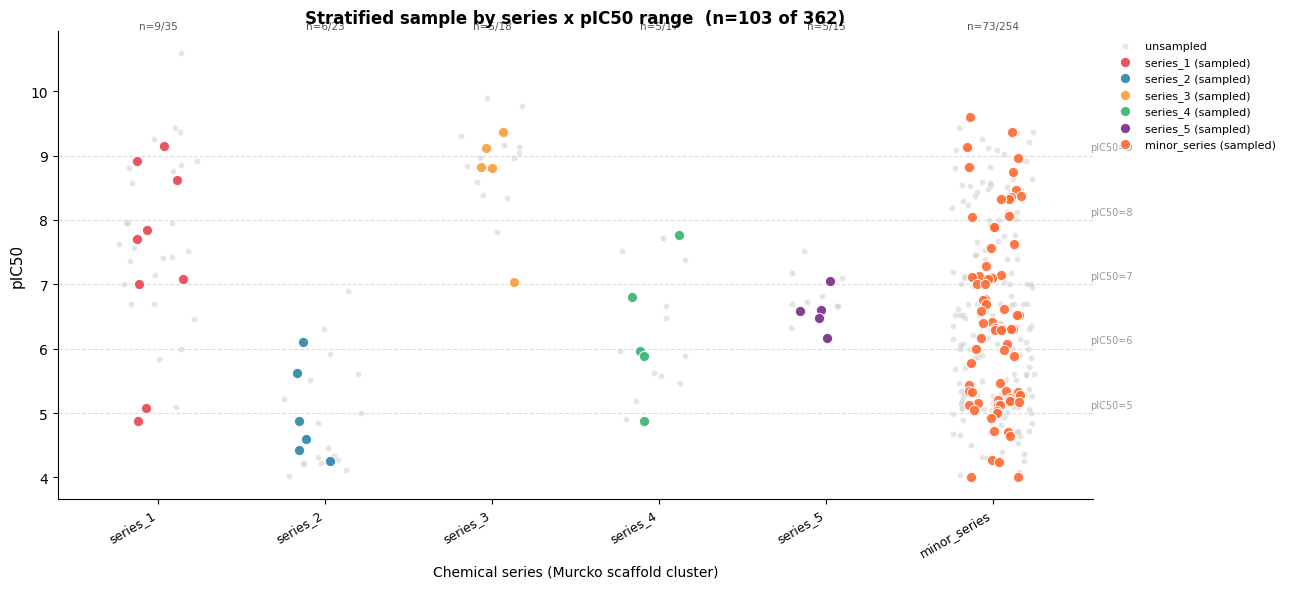

In [14]:
fig = plot_series_sample(
    df, sample,
    pic50_bins=PIC50_BINS[1:-1],   # drop the 0 and 15 sentinels
    figsize=(13, 6),
)
plt.tight_layout()
plt.show()

## 9. Export

In [15]:
out_csv  = Path("egfr_stratified_sample.csv")
out_plot = Path("egfr_stratified_sample_plot.png")

sample.to_csv(out_csv, index=False)
fig.savefig(out_plot, dpi=150, bbox_inches="tight")

print(f"Sample saved to : {out_csv.resolve()}")
print(f"Plot saved to   : {out_plot.resolve()}")

Sample saved to : C:\Users\rober\Downloads\stratosampler\stratosampler\notebooks\egfr_stratified_sample.csv
Plot saved to   : C:\Users\rober\Downloads\stratosampler\stratosampler\notebooks\egfr_stratified_sample_plot.png
